In [22]:
import numpy as np

print("STEP 1")

# (a) Create 6x4 matrix
np.random.seed(42)
scores = np.random.randint(0, 101, (6, 4))
print("\nOriginal Scores Matrix:\n", scores)

# (b) Normalize each column to [0,1] using broadcasting
min_vals = scores.min(axis=0)
max_vals = scores.max(axis=0)

normalized = (scores - min_vals) / (max_vals - min_vals)
print("\nNormalized Matrix:\n", normalized)

# (c) Boolean mask for students averaging >= 60
averages = scores.mean(axis=1)
mask = averages >= 60
print("\nStudent Averages:\n", averages)
print("\nPassing Mask:\n", mask)

passing_students = scores[mask]
print("\nPassing Students (>=60 avg):\n", passing_students)

# (d) Replace scores below 40 with column mean
col_means = scores.mean(axis=0)
updated_scores = np.where(scores < 40, col_means, scores)
print("\nScores after replacing <40 with column mean:\n", updated_scores)

# (e) Dot product with random weight vector
weights = np.random.rand(4)
weighted_scores = normalized.dot(weights)

print("\nWeight Vector:\n", weights)
print("\nWeighted Scores:\n", weighted_scores)

STEP 1

Original Scores Matrix:
 [[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]

Normalized Matrix:
 [[0.68493151 1.         0.         0.64556962]
 [0.80821918 0.2        0.93150685 0.83544304]
 [1.         0.8        1.         1.        ]
 [0.30136986 0.         0.09589041 0.40506329]
 [0.         0.94444444 0.20547945 0.21518987]
 [0.         0.67777778 0.61643836 0.        ]]

Student Averages:
 [57.   62.   83.5  24.5  38.5  35.75]

Passing Mask:
 [False  True  True False False False]

Passing Students (>=60 avg):
 [[60 20 82 86]
 [74 74 87 99]]

Scores after replacing <40 with column mean:
 [[51.         92.         48.66666667 71.        ]
 [60.         56.33333333 82.         86.        ]
 [74.         74.         87.         99.        ]
 [35.         56.33333333 48.66666667 52.        ]
 [35.         87.         48.66666667 60.83333333]
 [35.         63.         59.         60.83333333]]

Weight Vector:
 [0.61748151 0.61165316 0.00

In [23]:
import pandas as pd

print("STEP 2 ")
df = pd.read_csv("train.csv")
print("\n--- HEAD (10) ---\n", df.head(10))
print("\n--- TAIL (5) ---\n", df.tail(5))
print("\n--- SAMPLE (8) ---\n", df.sample(8, random_state=42))

print("\nDataset Shape:", df.shape)

print("\n--- INFO ---")
df.info()

print("\n--- DATA TYPES ---\n", df.dtypes)

print("\n--- COLUMN NAMES ---\n", df.columns.tolist())

categorical_cols = df.select_dtypes(include=['object']).shape[1]
numerical_cols = df.select_dtypes(include=['int64', 'float64']).shape[1]

print("\nNumber of Categorical Columns:", categorical_cols)
print("Number of Numerical Columns:", numerical_cols)


missing_columns = df.isnull().any().sum()
total_missing_cells = df.isnull().sum().sum()

print("\nColumns with ANY missing values:", missing_columns)
print("Total missing cells:", total_missing_cells)

STEP 2 

--- HEAD (10) ---
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarth

##Step 2:  Column Description

- PassengerId: Unique ID for each passenger  
- Survived: Whether passenger survived (0 = No, 1 = Yes)  
- Pclass: Ticket class (1 = upper, 3 = lower)  
- Name: Passenger’s name  
- Sex: Gender  
- Age: Age of passenger  
- SibSp: Number of siblings/spouses onboard  
- Parch: Number of parents/children onboard  
- Ticket: Ticket number  
- Fare: Amount paid for ticket  
- Cabin: Cabin number  
- Embarked: Port where passenger boarded

In [24]:
pip install missingno

STEP 3

Missing Values Per Column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Percentage Per Column:
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


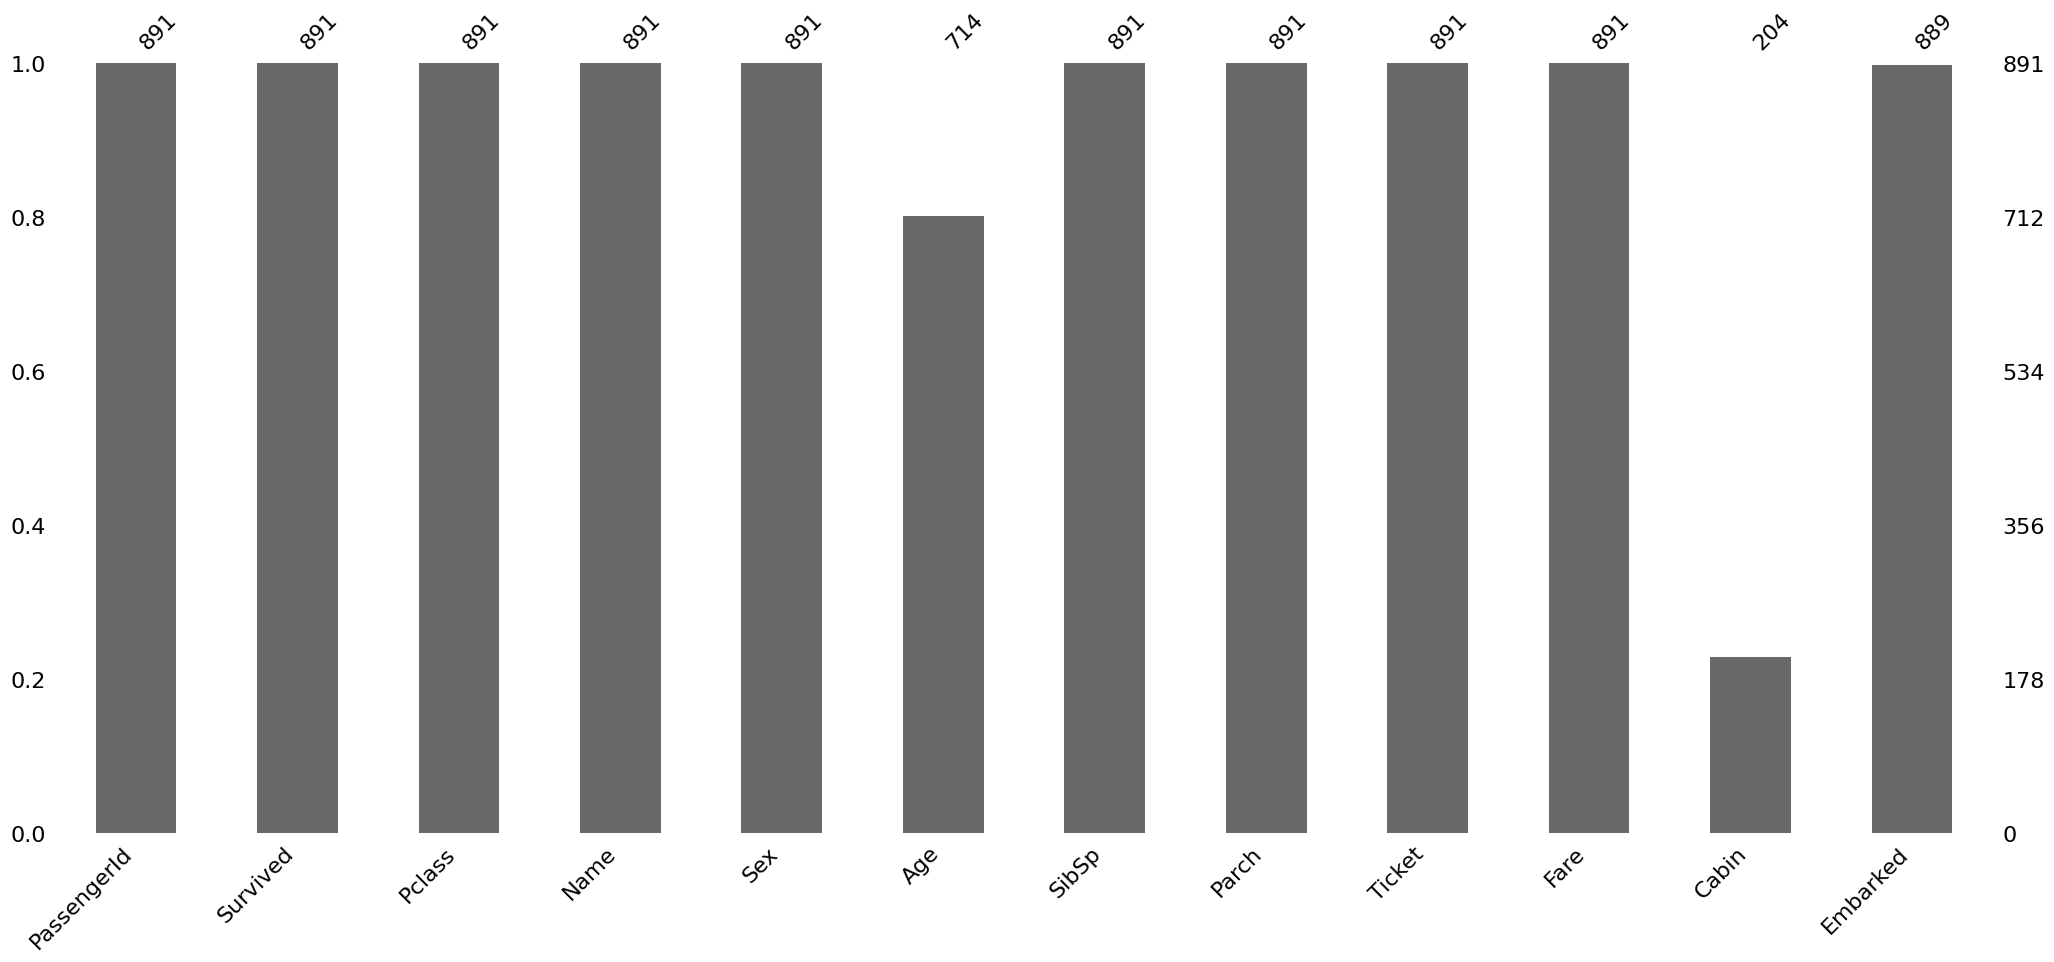


Top 3 Columns with Most Missing Data:
 Cabin       687
Age         177
Embarked      2
dtype: int64


In [25]:
import missingno as msno
import matplotlib.pyplot as plt

print("STEP 3")

missing_counts = df.isnull().sum()
print("\nMissing Values Per Column:\n", missing_counts)

missing_percent = (missing_counts / len(df)) * 100
print("\nMissing Percentage Per Column:\n", missing_percent)

msno.bar(df)
plt.show()

top_missing = missing_counts.sort_values(ascending=False).head(3)
print("\nTop 3 Columns with Most Missing Data:\n", top_missing)

## Step 3: Missing Value Analysis

**Cabin**  
- Missing because many passengers didn’t have recorded cabins  
- Best to drop it since most values are missing  

**Age**  
- Missing due to incomplete records  
- Fill using median  

**Embarked**  
- Only a few values missing  
- Fill using mode  


## Which column would you drop and why?

I would drop the Cabin column because most of its data is missing, so it won’t be very useful.


## Risk of dropping vs filling

- Dropping may remove useful info but avoids wrong assumptions  
- Filling keeps data complete but can introduce some bias  

In [26]:
print("STEP 4")

old_dtypes = df.dtypes

df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

new_dtypes = df.dtypes

comparison = pd.DataFrame({
    'Column': df.columns,
    'Old Dtype': old_dtypes.values,
    'New Dtype': new_dtypes.values
})

print("\n--- Before/After Dtype Comparison ---\n")
print(comparison)

# Final info
print("\n--- UPDATED INFO ---")
df.info()

STEP 4

--- Before/After Dtype Comparison ---

         Column Old Dtype New Dtype
0   PassengerId     int64     int64
1      Survived     int64  category
2        Pclass     int64  category
3          Name    object    object
4           Sex    object  category
5           Age   float64   float64
6         SibSp     int64     int64
7         Parch     int64     int64
8        Ticket    object    object
9          Fare   float64   float64
10        Cabin    object    object
11     Embarked    object  category

--- UPDATED INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp    

In [27]:
print("STEP 5: HANDLING MISSING VALUES")

df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['has_cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

print("\nTotal Missing Values After Cleaning:", df.isnull().sum().sum())

STEP 5: HANDLING MISSING VALUES

Total Missing Values After Cleaning: 0


/tmp/ipykernel_9738/2699801242.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Pclass', 'Sex'])['Age'].transform('median')


## Step 5: Handling Missing Values

- After cleaning, there are **no missing values left in the dataset**.  
- Age was filled using group median (Pclass + Sex).  
- Embarked was filled using mode.  
- Cabin was replaced with a binary feature (has_cabin) and original column was removed.

STEP 6: OUTLIER DETECTION 

Fare Outliers Count: 116

Age Outliers Count: 33


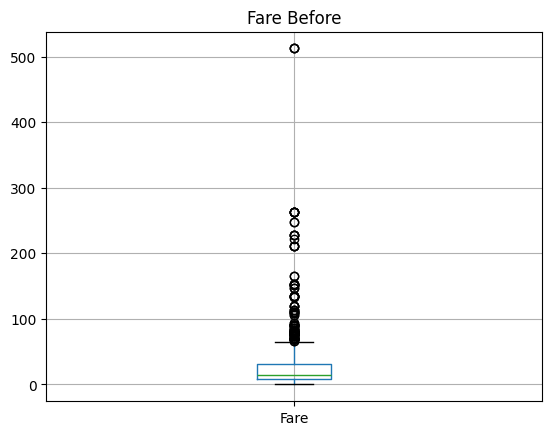

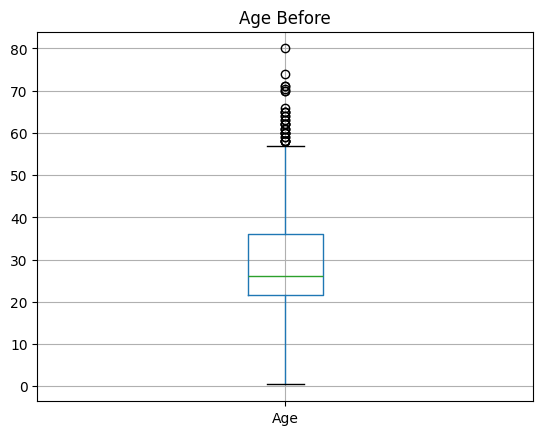

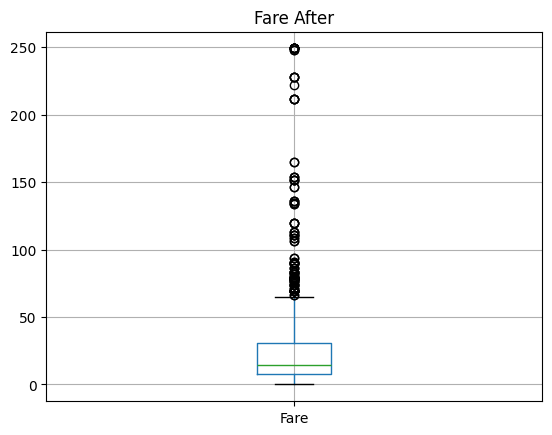

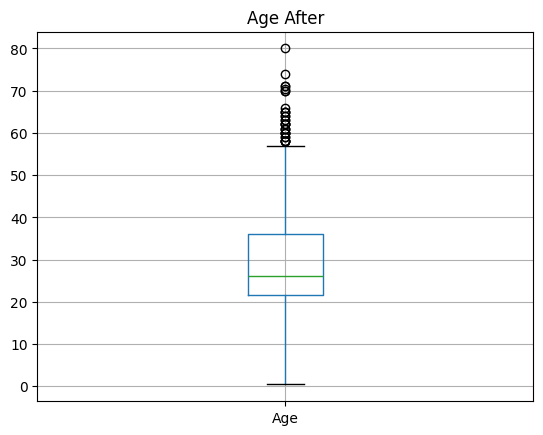

In [28]:
import matplotlib.pyplot as plt

print("STEP 6: OUTLIER DETECTION ")

def compute_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col} Outliers Count:", len(outliers))
    return lower, upper

fare_lower, fare_upper = compute_outliers('Fare')

age_lower, age_upper = compute_outliers('Age')

# Boxplots before
df[['Fare']].boxplot()
plt.title("Fare Before")
plt.show()

df[['Age']].boxplot()
plt.title("Age Before")
plt.show()

cap_value = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=cap_value)

# Boxplots after
df[['Fare']].boxplot()
plt.title("Fare After")
plt.show()

df[['Age']].boxplot()
plt.title("Age After")
plt.show()

## Step 6: Outlier Detection

- **Fare:** 116 outliers found  
- **Age:** 33 outliers found  

### Observation
- Fare has more extreme values because of luxury tickets.  
- Age outliers are fewer and still realistic values.  

### Decision
Outliers were not removed blindly since they represent real passengers, especially in Fare.

## Analysis: Why capping (winsorization) is better than dropping outliers

Capping is often better because it keeps all the data while reducing the effect of extreme values. In real-world datasets, outliers are not always errors,they can be valid but rare cases (like very high Titanic fares).

If we drop outliers, we lose useful information and reduce dataset size, which can hurt model performance. But if we cap them, we control their impact without removing the data completely.

So overall, capping is preferred because it balances data quality and data retention.

In [29]:
print("STEP 7: FEATURE ENGINEERING")

df['family_size'] = df['SibSp'] + df['Parch'] + 1

df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)

df['fare_per_person'] = df['Fare'] / df['family_size']

df['title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = df['title'].value_counts()[df['title'].value_counts() < 10].index
df['title'] = df['title'].replace(rare_titles, 'Rare')

df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

df['deck'] = df['Name'].copy()
df['deck'] = df['has_cabin'].map({0: 'Unknown', 1: 'Known'})

df['fare_bin'] = pd.qcut(df['Fare'], q=4, labels=['Low','Medium','High','VHigh'])

print("\nFamily Size:\n", df['family_size'].head())
print("\nIs Alone:\n", df['is_alone'].value_counts())
print("\nTitle:\n", df['title'].value_counts())
print("\nAge Group:\n", df['age_group'].value_counts())
print("\nDeck:\n", df['deck'].value_counts())
print("\nFare Bin:\n", df['fare_bin'].value_counts())

print("\nFirst 10 Rows (New Features):\n",
      df[['family_size','is_alone','fare_per_person','title','age_group','deck','fare_bin']].head(10))

STEP 7: FEATURE ENGINEERING

Family Size:
 0    2
1    2
2    1
3    2
4    1
Name: family_size, dtype: int64

Is Alone:
 is_alone
1    537
0    354
Name: count, dtype: int64

Title:
 title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Age Group:
 age_group
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

Deck:
 deck
Unknown    687
Known      204
Name: count, dtype: int64

Fare Bin:
 fare_bin
Medium    224
Low       223
High      222
VHigh     222
Name: count, dtype: int64

First 10 Rows (New Features):
    family_size  is_alone  fare_per_person   title age_group     deck fare_bin
0            2         0          3.62500      Mr     Adult  Unknown      Low
1            2         0         35.64165     Mrs     Adult    Known    VHigh
2            1         1          7.92500    Miss     Adult  Unknown   Medium
3            2         0         26.55000     Mrs     Adult    Known    VHigh
4            1 

In [30]:
print("STEP 8: ENCODING")

df['sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)

title_dummies = pd.get_dummies(df['title'], prefix='title', drop_first=True)
df = pd.concat([df, title_dummies], axis=1)

age_map = {'Child':0, 'Teen':1, 'Adult':2, 'Senior':3}
df['age_group_encoded'] = df['age_group'].map(age_map)

fare_map = {'Low':0, 'Medium':1, 'High':2, 'VHigh':3}
df['fare_bin_encoded'] = df['fare_bin'].map(fare_map)

print("\nDataset Shape After Encoding:", df.shape)

features = df.columns.tolist()
print("\nML Features:\n", features)

STEP 8: ENCODING

Dataset Shape After Encoding: (891, 29)

ML Features:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'has_cabin', 'family_size', 'is_alone', 'fare_per_person', 'title', 'age_group', 'deck', 'fare_bin', 'sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare', 'age_group_encoded', 'fare_bin_encoded']


In [38]:
from sklearn.preprocessing import StandardScaler

print("STEP 9: SCALING")

cols = ['Age','Fare','fare_per_person','family_size']

print("\nBefore Scaling:")
for col in cols:
    print(col, "Mean:", df[col].mean(), "Std:", df[col].std())

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

print("\nAfter Scaling:")
for col in cols:
    print(col, "Mean:", df[col].mean(), "Std:", df[col].std())

final_df = df.drop(columns=['Name','Ticket','PassengerId'])

print("\n--- FINAL DATASET INFO ---")
final_df.info()

print("\n--- FINAL HEAD ---\n", final_df.head())

final_df.to_csv("titanic_cleaned.csv", index=False)

STEP 9: SCALING

Before Scaling:
Age Mean: 2.153159805333637e-16 Std: 1.000561640033044
Fare Mean: -5.582266161976096e-17 Std: 1.0005616400330446
fare_per_person Mean: 1.993666486420034e-17 Std: 1.000561640033046
family_size Mean: -2.392399783704041e-17 Std: 1.000561640033051

After Scaling:
Age Mean: 1.1961998918520205e-17 Std: 1.000561640033044
Fare Mean: 5.980999459260102e-18 Std: 1.0005616400330446
fare_per_person Mean: 1.1961998918520205e-17 Std: 1.000561640033046
family_size Mean: -9.170865837532157e-17 Std: 1.0005616400330515

--- FINAL DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Survived             891 non-null    int64   
 1   Pclass               891 non-null    category
 2   Sex                  891 non-null    category
 3   Age                  891 non-null    float64 
 4   SibSp            

STEP 10: SURVIVAL ANALYSIS

Pclass Survival:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


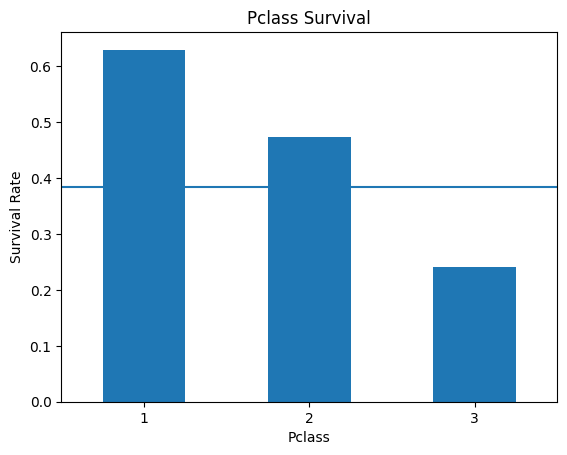


Sex Survival:
 Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


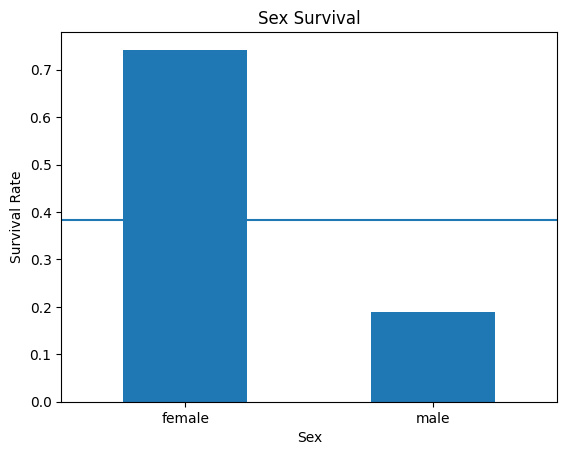


Pclass + Sex:
 Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


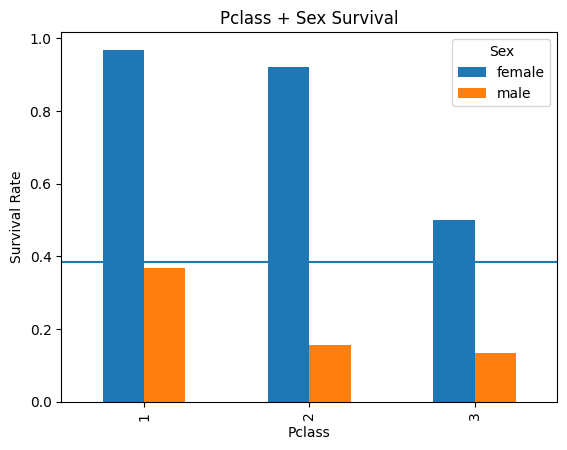


Age Group:
 age_group
Child     0.580
Teen      0.429
Adult     0.366
Senior    0.227
Name: Survived, dtype: float64


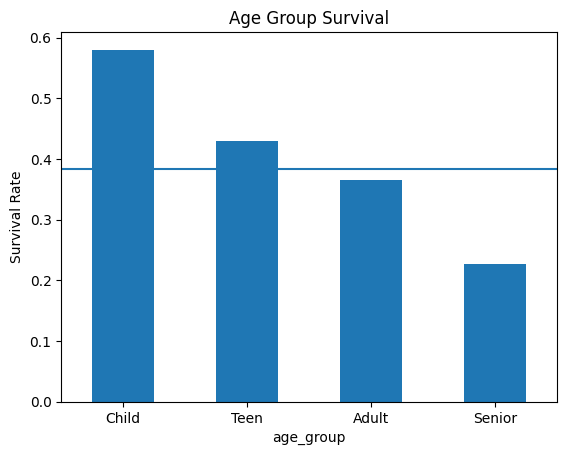


Is Alone:
 is_alone
0    0.506
1    0.304
Name: Survived, dtype: float64


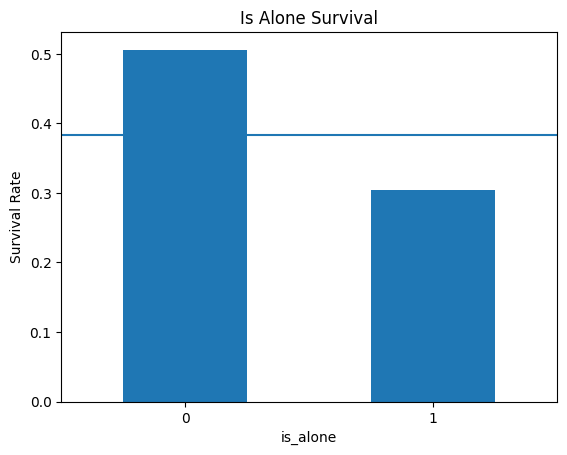


Embarked:
 Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


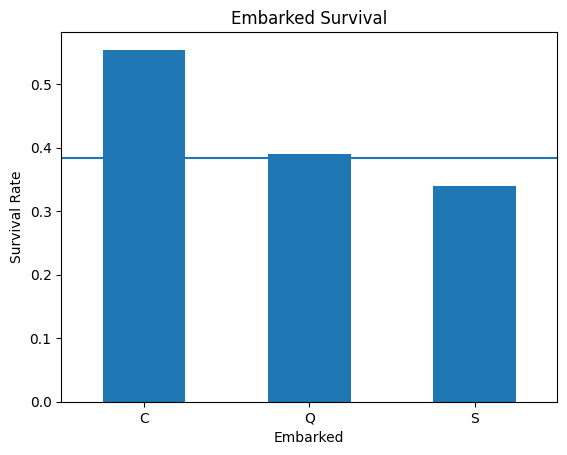

In [32]:
print("STEP 10: SURVIVAL ANALYSIS")

df['Survived'] = df['Survived'].astype(int)

overall_rate = df['Survived'].mean()

def plot_bar(series, title):
    ax = series.plot(kind='bar')
    plt.axhline(y=overall_rate)
    plt.title(title)
    plt.ylabel("Survival Rate")
    plt.xticks(rotation=0)
    plt.show()

pclass_survival = df.groupby('Pclass', observed=False)['Survived'].mean().round(3)
print("\nPclass Survival:\n", pclass_survival)
plot_bar(pclass_survival, "Pclass Survival")

sex_survival = df.groupby('Sex', observed=False)['Survived'].mean().round(3)
print("\nSex Survival:\n", sex_survival)
plot_bar(sex_survival, "Sex Survival")

combo = df.groupby(['Pclass','Sex'], observed=False)['Survived'].mean().unstack().round(3)
print("\nPclass + Sex:\n", combo)
combo.plot(kind='bar')
plt.axhline(y=overall_rate)
plt.title("Pclass + Sex Survival")
plt.ylabel("Survival Rate")
plt.show()

age_survival = df.groupby('age_group', observed=False)['Survived'].mean().round(3)
print("\nAge Group:\n", age_survival)
plot_bar(age_survival, "Age Group Survival")

alone_survival = df.groupby('is_alone')['Survived'].mean().round(3)
print("\nIs Alone:\n", alone_survival)
plot_bar(alone_survival, "Is Alone Survival")

emb_survival = df.groupby('Embarked', observed=False)['Survived'].mean().round(3)
print("\nEmbarked:\n", emb_survival)
plot_bar(emb_survival, "Embarked Survival")

## Step 10: Survival Analysis

- Sex is the strongest predictor of survival  

### Evidence
- Female survival rate = 0.742  
- Male survival rate = 0.189  
- Difference = 0.553 (very large gap)  

- Pclass difference (best vs worst):
  - Class 1 = 0.630  
  - Class 3 = 0.242  
  - Difference = 0.388  

### Conclusion
- Sex shows a larger impact than Pclass or any other factor  
- Therefore, gender is the most influential factor in predicting survival  

### Reason
- Priority was given to women during evacuation  
- This created a strong survival advantage for female passengers  

In [33]:
print("STEP 11: ADVANCED AGGREGATION")

agg_df = df.groupby('Pclass').agg({
    'Fare': ['mean','median','std','min','max', lambda x: (x > 50).mean()*100],
    'Age': ['mean','median', lambda x: x.quantile(0.75)-x.quantile(0.25)],
    'Survived': ['mean','count']
})

print("\nAggregated Table:\n", agg_df)

df['class_avg_fare'] = df.groupby('Pclass')['Fare'].transform('mean')
df['class_survival_rate'] = df.groupby('Pclass')['Survived'].transform(lambda x: x.astype(int).mean())

print("\nFirst 15 Rows:\n", df[['Pclass','Fare','class_avg_fare','class_survival_rate']].head(15))

STEP 11: ADVANCED AGGREGATION

Aggregated Table:
            Fare                                                          Age  \
           mean    median       std       min       max <lambda_0>      mean   
Pclass                                                                         
1       1.15034  0.683825  1.453492 -0.734696  5.124239        0.0  0.688732   
2      -0.24853 -0.399404  0.315702 -0.734696  0.994705        0.0  0.056463   
3      -0.41292 -0.545285  0.277131 -0.734696  0.901765        0.0 -0.324145   

                             Survived        
          median <lambda_0>      mean count  
Pclass                                       
1       0.668392   1.372495  0.629630   216  
2       0.066750   0.977667  0.472826   184  
3      -0.309276   0.658045  0.242363   491  

First 15 Rows:
    Pclass      Fare  class_avg_fare  class_survival_rate
0       3 -0.564109        -0.41292             0.242363
1       1  0.942548         1.15034             0.629630
2    

/tmp/ipykernel_9738/3576862086.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby('Pclass').agg({
/tmp/ipykernel_9738/3576862086.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['class_avg_fare'] = df.groupby('Pclass')['Fare'].transform('mean')
/tmp/ipykernel_9738/3576862086.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['class_survival_rate'] = df.groupby('Pclass')['Survived'].transf

STEP 12: PIVOT TABLES

Pivot 1:
 Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


/tmp/ipykernel_9738/1727175023.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = pd.pivot_table(df, values='Survived', index='Pclass', columns='Sex', aggfunc='mean')


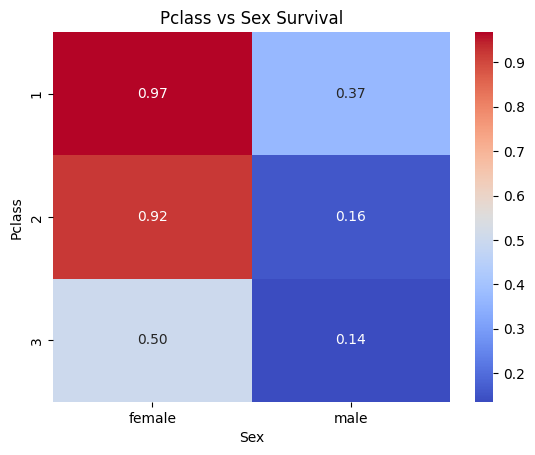

/tmp/ipykernel_9738/1727175023.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(df, values='Survived', index='age_group', columns='Pclass', aggfunc=['mean','count'])
/tmp/ipykernel_9738/1727175023.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot2 = pd.pivot_table(df, values='Survived', index='age_group', columns='Pclass', aggfunc=['mean','count'])
/tmp/ipykernel_9738/1727175023.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = pd.pivot_table(df, values='


Pivot 2:
                mean                     count          
Pclass            1         2         3     1    2    3
age_group                                              
Child      0.750000  1.000000  0.416667     4   17   48
Teen       0.916667  0.500000  0.282609    12   12   46
Adult      0.639785  0.414474  0.216837   186  152  392
Senior     0.214286  0.333333  0.200000    14    3    5

Pivot 3:
 Pclass         1         2         3
title                               
Master  2.088816 -0.122935 -0.063818
Miss    1.424115 -0.428815 -0.528668
Mr      0.262945 -0.428815 -0.548914
Mrs     1.134116 -0.122935 -0.358816
Rare    0.197063 -0.428815       NaN


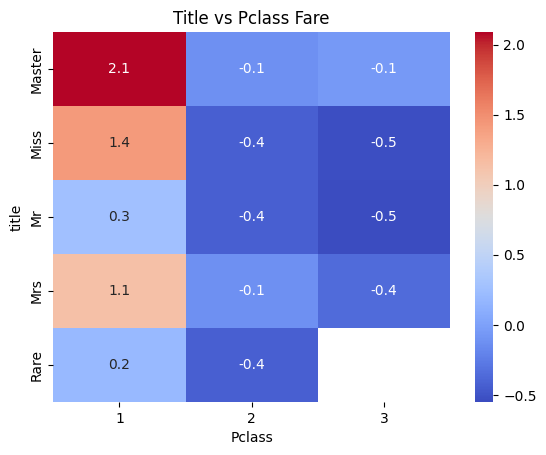

In [34]:
import seaborn as sns

print("STEP 12: PIVOT TABLES")

pivot1 = pd.pivot_table(df, values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
print("\nPivot 1:\n", pivot1)

sns.heatmap(pivot1, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pclass vs Sex Survival")
plt.show()

pivot2 = pd.pivot_table(df, values='Survived', index='age_group', columns='Pclass', aggfunc=['mean','count'])
print("\nPivot 2:\n", pivot2)

pivot3 = pd.pivot_table(df, values='Fare', index='title', columns='Pclass', aggfunc='median')
print("\nPivot 3:\n", pivot3)

sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Title vs Pclass Fare")
plt.show()

##Step 12: Analysis
Highest survival: Female in Pclass 1 (0.968)  
Lowest survival: Male in Pclass 3 (0.135)  

This is due to “women and children first” policy and higher priority given to upper-class passengers for lifeboats. Lower-class males were last in evacuation order and had less access to safety.

STEP 13: CORRELATION ANALYSIS


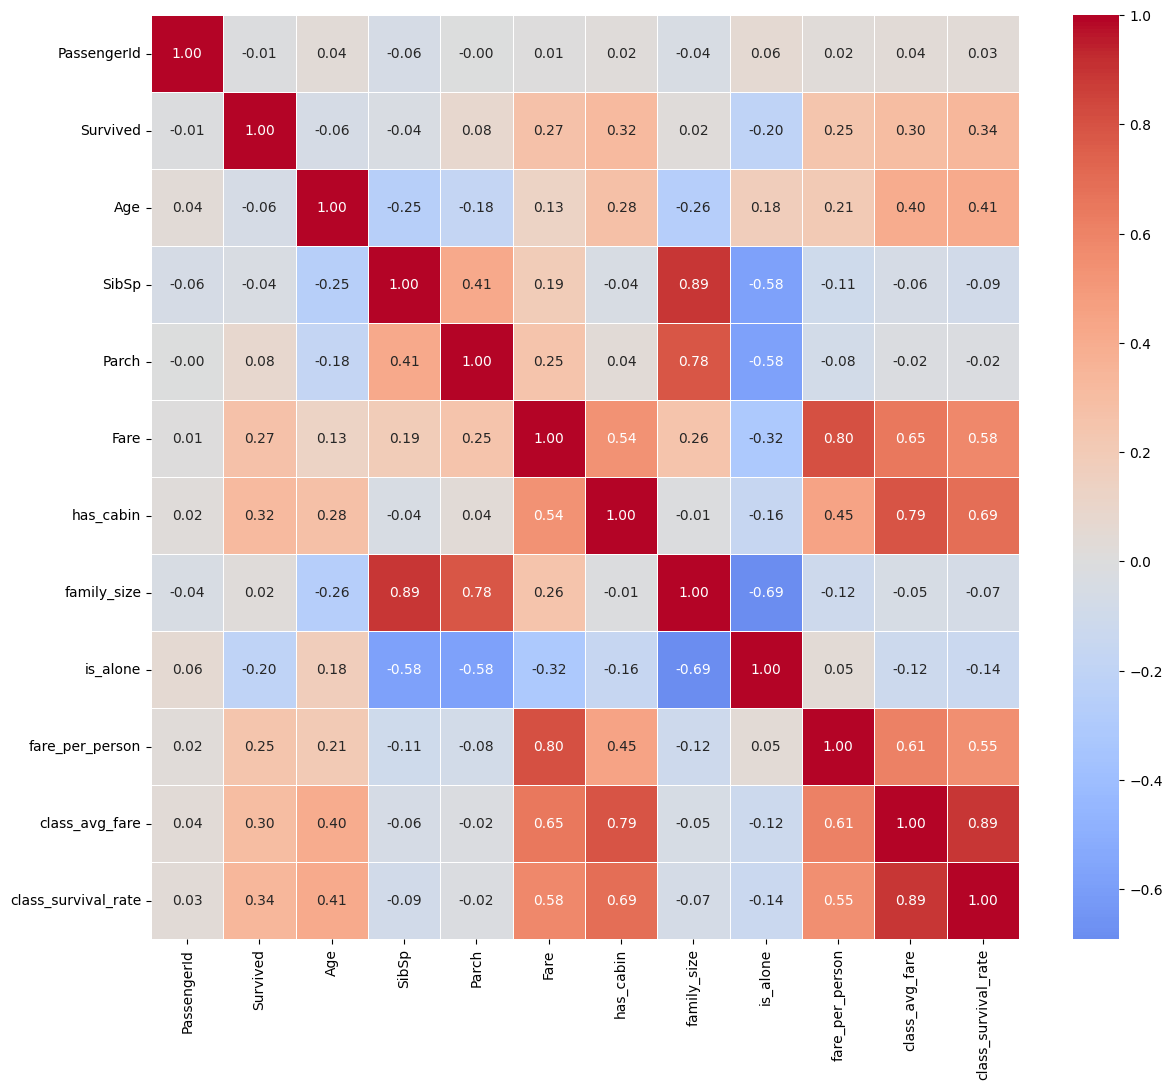


Correlation with Survived:
 Survived               1.000000
class_survival_rate    0.339817
has_cabin              0.316912
class_avg_fare         0.302441
Fare                   0.273008
fare_per_person        0.246441
Parch                  0.081629
family_size            0.016639
PassengerId           -0.005007
SibSp                 -0.035322
Age                   -0.059579
is_alone              -0.203367
Name: Survived, dtype: float64

High Correlation Pairs:
                      PassengerId  Survived  Age     SibSp     Parch      Fare  \
PassengerId                  NaN       NaN  NaN       NaN       NaN       NaN   
Survived                     NaN       NaN  NaN       NaN       NaN       NaN   
Age                          NaN       NaN  NaN       NaN       NaN       NaN   
SibSp                        NaN       NaN  NaN       NaN       NaN       NaN   
Parch                        NaN       NaN  NaN       NaN       NaN       NaN   
Fare                         NaN       NaN  

In [35]:
print("STEP 13: CORRELATION ANALYSIS")

df['Survived'] = df['Survived'].astype(int)

num_df = df.select_dtypes(include=['int64','float64','int32'])

corr = num_df.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.show()

surv_corr = corr['Survived'].sort_values(ascending=False)
print("\nCorrelation with Survived:\n", surv_corr)

high_corr = corr[(corr > 0.7) & (corr < 1.0)]
print("\nHigh Correlation Pairs:\n", high_corr)

low_corr = surv_corr[abs(surv_corr) < 0.05]
print("\nNear Zero Correlation:\n", low_corr)

##Step 13: Analysis
Selected 5 features for Logistic Regression:

1. class_survival_rate
2. has_cabin
3. class_avg_fare
4. fare_per_person
5. is_alone

Reason:
These features have the highest correlation with Survived and capture class, wealth, family structure, and survival context, which are the strongest predictors in the dataset.

In [36]:
print("STEP 14: NUMPY PERFORMANCE & SURVIVAL COMPUTATION")

num_df = df.select_dtypes(include=['int64','float64','int32']).copy()

arr = num_df.values
cols = list(num_df.columns)

print("\n(a) Column-wise Statistics:")

mean_vals = np.mean(arr, axis=0)
std_vals = np.std(arr, axis=0)
min_vals = np.min(arr, axis=0)
max_vals = np.max(arr, axis=0)
median_vals = np.median(arr, axis=0)

print("Mean:\n", mean_vals)
print("Std:\n", std_vals)
print("Min:\n", min_vals)
print("Max:\n", max_vals)
print("Median:\n", median_vals)

print("\n(b) Z-score Matrix:")

z = (arr - mean_vals) / std_vals

print("Z-score mean (approx 0):", np.mean(z, axis=0))
print("Z-score std (approx 1):", np.std(z, axis=0))

print("\n(c) Correlation Comparison:")

np_corr = np.corrcoef(arr, rowvar=False)
pd_corr = num_df.corr().values

comparison = np.allclose(np_corr, pd_corr)
print("Are NumPy and Pandas correlations equal? ->", comparison)

diff = np.abs(np_corr - pd_corr)
print("Max difference between matrices:", np.max(diff))

print("\n(d) Survival Group Analysis:")

surv_col = cols.index('Survived')
age_col = cols.index('Age')
fare_col = cols.index('Fare')

survived = arr[arr[:, surv_col] == 1]
not_survived = arr[arr[:, surv_col] == 0]

surv_mean_age = np.mean(survived[:, age_col])
surv_mean_fare = np.mean(survived[:, fare_col])

nonsurv_mean_age = np.mean(not_survived[:, age_col])
nonsurv_mean_fare = np.mean(not_survived[:, fare_col])

print("\nSurvivors Mean Age:", surv_mean_age)
print("Survivors Mean Fare:", surv_mean_fare)

print("\nNon-Survivors Mean Age:", nonsurv_mean_age)
print("Non-Survivors Mean Fare:", nonsurv_mean_fare)

fare_diff = surv_mean_fare - nonsurv_mean_fare
print("\nFare Difference:", fare_diff)

STEP 14: NUMPY PERFORMANCE & SURVIVAL COMPUTATION

(a) Column-wise Statistics:
Mean:
 [ 4.46000000e+02  3.83838384e-01  2.15315981e-16  5.23007856e-01
  3.81593715e-01 -5.58226616e-17  2.28956229e-01 -2.39239978e-17
  6.02693603e-01  1.99366649e-17 -2.79113308e-17  3.83838384e-01]
Std:
 [2.57209383e+02 4.86319318e-01 1.00000000e+00 1.10212444e+00
 8.05604761e-01 1.00000000e+00 4.20161010e-01 1.00000000e+00
 4.89340397e-01 1.00000000e+00 6.53842095e-01 1.65259760e-01]
Min:
 [ 1.          0.         -2.157819    0.          0.         -0.734696
  0.         -0.56097483  0.         -0.67537769 -0.41292028  0.24236253]
Max:
 [8.91000000e+02 1.00000000e+00 3.82700942e+00 8.00000000e+00
 6.00000000e+00 5.12423873e+00 1.00000000e+00 5.64037224e+00
 1.00000000e+00 8.10144520e+00 1.15033963e+00 6.29629630e-01]
Median:
 [ 4.46000000e+02  0.00000000e+00 -2.34070433e-01  0.00000000e+00
  0.00000000e+00 -3.94599216e-01  0.00000000e+00 -5.60974830e-01
  1.00000000e+00 -3.82824236e-01 -4.12920280e-01

## Step 14: Analysis

- The average fare of survivors is higher than non-survivors.  
- Fare difference ≈ 0.56 (after scaling).  

This shows that passengers who paid higher fares had better chances of survival. It suggests that higher-class (wealthier) passengers were given more priority and had better access to safety during evacuation.

STEP 15: TITANIC EDA DASHBOARD


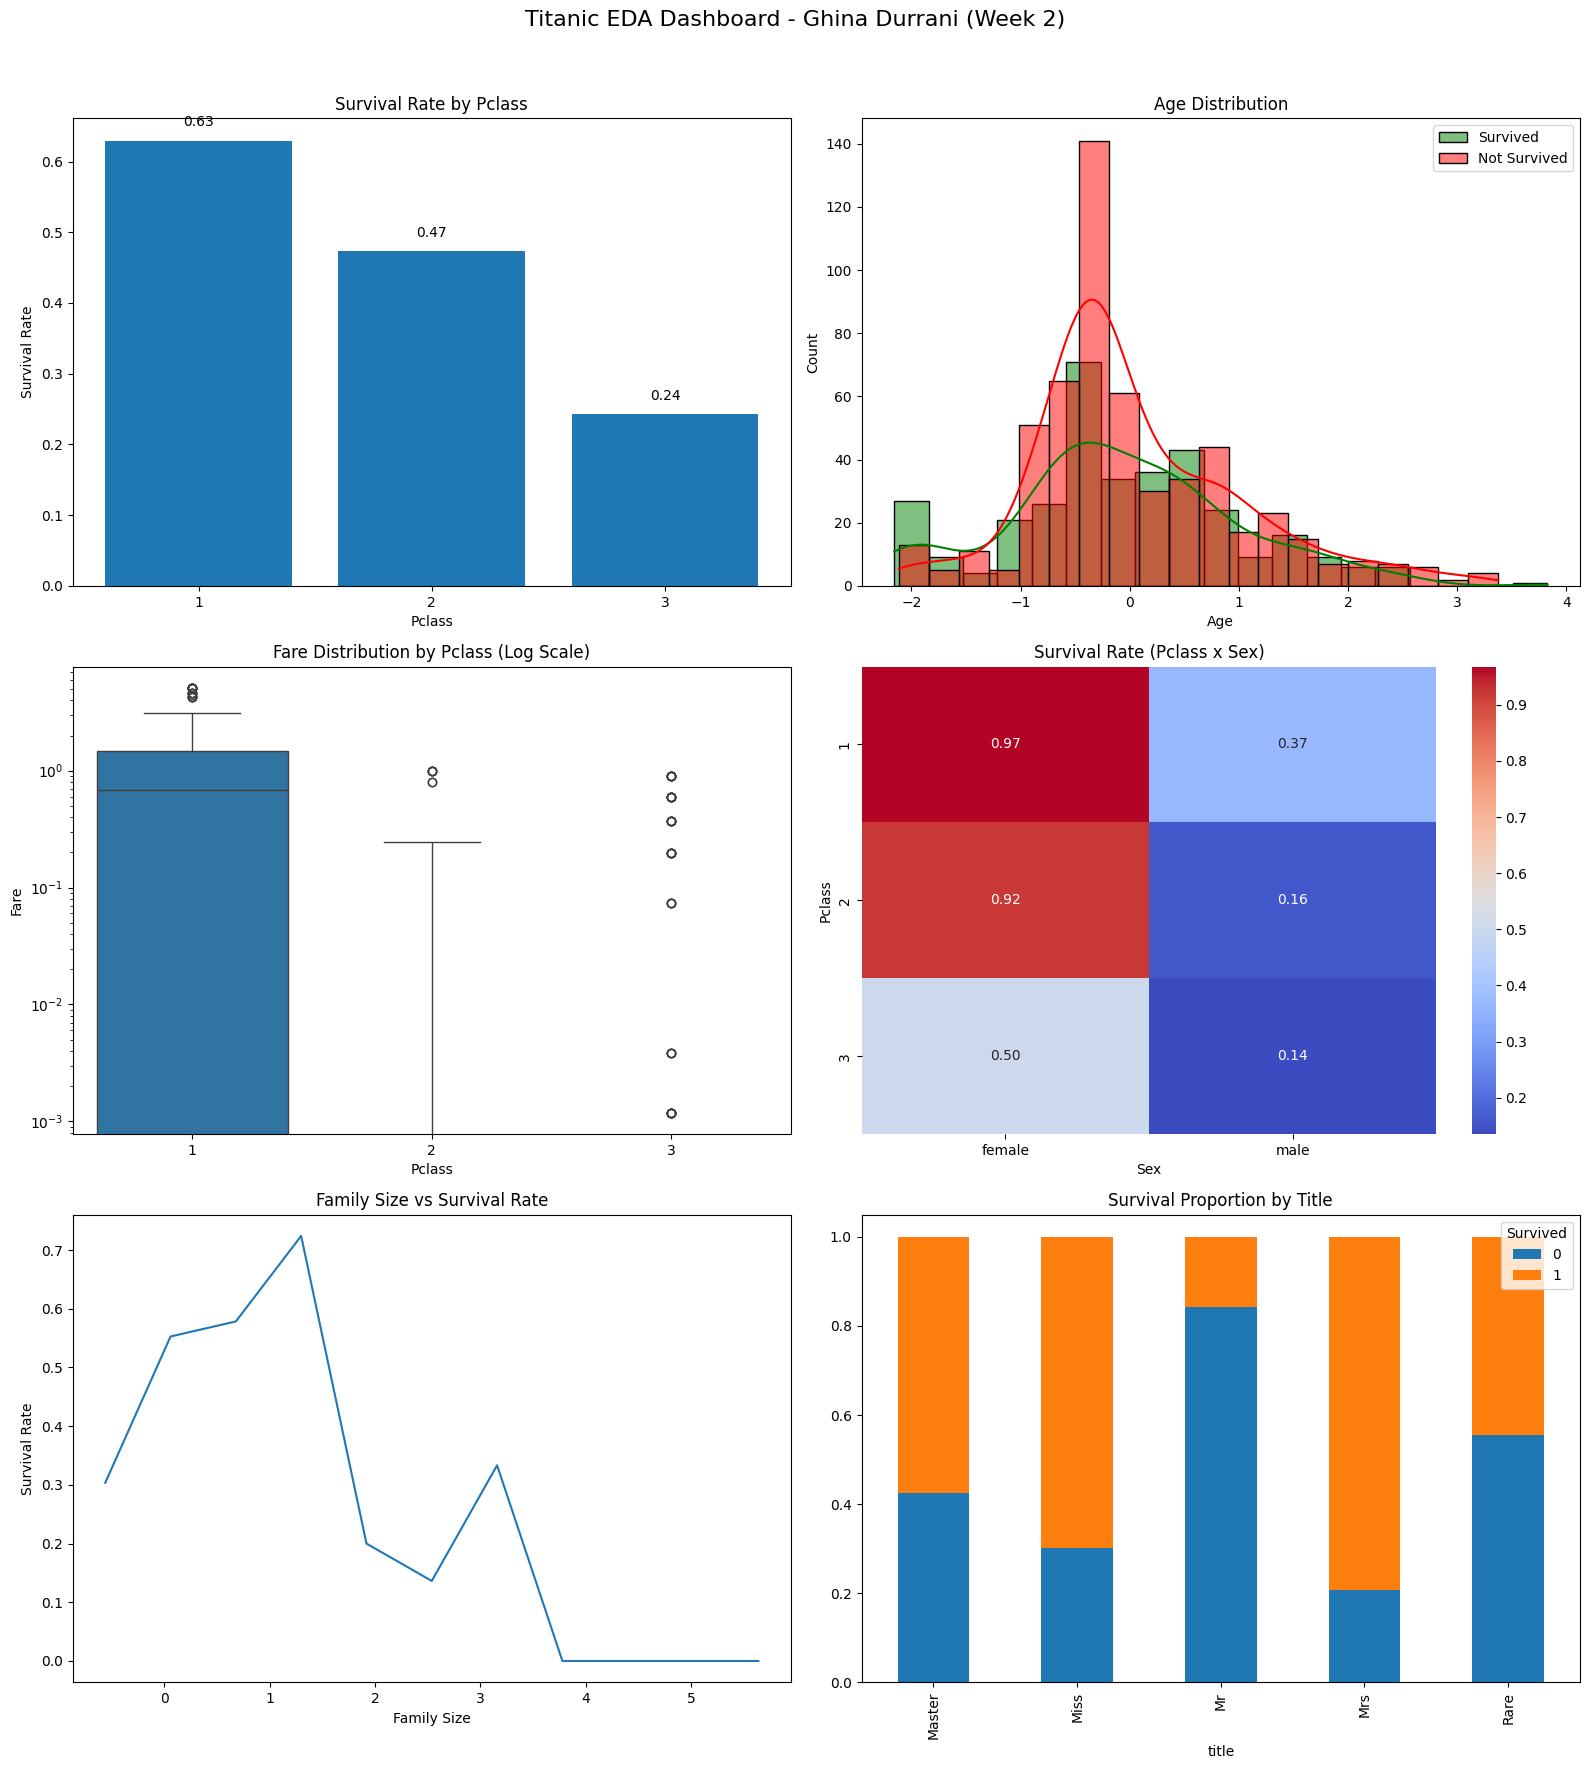

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

print("STEP 15: TITANIC EDA DASHBOARD")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

pclass_survival = df.groupby('Pclass', observed=False)['Survived'].mean()
axes[0,0].bar(pclass_survival.index.astype(str), pclass_survival.values)
axes[0,0].set_title("Survival Rate by Pclass")
axes[0,0].set_xlabel("Pclass")
axes[0,0].set_ylabel("Survival Rate")
for i, v in enumerate(pclass_survival.values):
    axes[0,0].text(i, v + 0.02, f"{v:.2f}", ha='center')

sns.histplot(df[df['Survived']==1]['Age'], kde=True, color='green', label='Survived', ax=axes[0,1])
sns.histplot(df[df['Survived']==0]['Age'], kde=True, color='red', label='Not Survived', ax=axes[0,1])
axes[0,1].set_title("Age Distribution")
axes[0,1].legend()

sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title("Fare Distribution by Pclass (Log Scale)")

pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', observed=False)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Survival Rate (Pclass x Sex)")

family_survival = df.groupby('family_size')['Survived'].mean()
sns.lineplot(x=family_survival.index, y=family_survival.values, ax=axes[2,0])
axes[2,0].set_title("Family Size vs Survival Rate")
axes[2,0].set_xlabel("Family Size")
axes[2,0].set_ylabel("Survival Rate")

title_survival = pd.crosstab(df['title'], df['Survived'], normalize='index')
title_survival.plot(kind='bar', stacked=True, ax=axes[2,1])
axes[2,1].set_title("Survival Proportion by Title")

plt.suptitle("Titanic EDA Dashboard - Ghina Durrani (Week 2)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("titanic_dashboard.png", dpi=150)

plt.show()

#Analysis Report Of Titanic Dataset

## (1) Executive Summary

This analysis is based on the Titanic dataset, which contains passenger information such as age, sex, class, fare, and survival status. The main goal of this project was to explore patterns in survival and understand which factors had the strongest influence. The dataset was cleaned, missing values were handled, and new features were created to improve analysis.

The top three findings are:  
1. Gender played the most important role in survival, with females having a much higher survival rate than males.  
2. Passenger class strongly affected survival, with first-class passengers having better chances.  
3. Fare was also an important indicator, as higher-paying passengers were more likely to survive.

---

## (2) Data Quality Assessment

The dataset had several quality issues, mainly missing values in Age, Cabin, and Embarked columns. The Cabin column had a very high percentage of missing data, making it unreliable for direct analysis. Age had moderate missing values, while Embarked had only a few missing entries.

To handle this, different strategies were used. Age was filled using median values grouped by Pclass and Sex to maintain realistic distributions. Embarked was filled using mode, and Cabin was transformed into a binary feature instead of being used directly. This approach ensured that no important information was lost while maintaining data reliability for machine learning tasks.

---

## (3) Feature Engineering Rationale

Several new features were created to improve model performance. Family size was calculated using SibSp and Parch to understand group travel impact. A binary feature (is_alone) was created to identify solo travelers. Fare per person was added to normalize ticket cost impact.

Titles were extracted from names to capture social status, which often correlates with survival chances. Age was grouped into categories (Child, Teen, Adult, Senior) to simplify patterns. Fare was also binned into categories to reduce skewness. A has_cabin feature was added to indicate whether cabin information was available. These engineered features help machine learning models capture hidden patterns more effectively.

---

## (4) Key Statistical Findings

Survival analysis shows clear patterns across different groups. Females had a survival rate of 0.742 compared to 0.189 for males, showing a strong gender-based difference. Passenger class also played a major role: first-class passengers had a survival rate of around 0.63, while third-class passengers had only 0.24.

Age groups showed that children had a higher survival rate compared to adults and seniors. Passengers traveling alone had lower survival rates compared to those with family members. Fare analysis showed that survivors paid significantly higher fares on average compared to non-survivors. The difference in fare between survivors and non-survivors confirms that socio-economic status strongly influenced survival chances. Overall, gender, class, and fare were the most important statistical indicators.

---

## (5) Visualization Insights

The visualizations clearly highlight survival patterns. The bar chart of survival rate by Pclass shows that higher classes had better survival chances. The age distribution plot shows that younger passengers had slightly better survival probability. The boxplot of fare reveals extreme outliers, especially in first class, which confirms wealth disparity.

The heatmap of Pclass and Sex is the most powerful visualization, clearly showing that females in first class had the highest survival rate. Family size vs survival line plot shows that small families had better survival chances compared to large families or solo travelers. The title-based chart shows that social status also influenced survival. Overall, the Pclass-Sex heatmap is the most useful for prediction.

---

## (6) Feature Selection Recommendation

For a machine learning classifier, the most useful features are: Pclass, Sex, Age, Fare, family_size, has_cabin, and title. These features were selected because they show strong correlation with survival and capture important social and economic factors.

Pclass and Fare represent economic status, while Sex is the strongest survival predictor. Age and family_size help understand demographic patterns. has_cabin gives additional information about passenger class and documentation quality. Title captures social hierarchy. These features together provide a balanced mix of numerical, categorical, and engineered variables for better model performance.

---

## (7) Reflection

The most challenging part of this project was handling missing values and deciding the correct imputation strategy. Understanding when to use median, mode, or feature creation required careful thinking. Another difficult part was feature engineering, especially extracting meaningful information from names and ticket data.

The biggest surprise was how strongly gender affected survival compared to other features. It was also interesting to see how passenger class consistently influenced almost every aspect of survival. If I were to do this again, I would explore more advanced feature engineering techniques and try additional models to compare performance. I would also focus more on visualization design to make insights even clearer.